# Fase 5: Confronto dei Modelli e Valutazione sul Test Set

In questo notebook vengono caricati i risultati delle valutazioni memorizzati nel file `model_evaluation_results.csv`, con confronto grafico delle performance dei modelli sul validation set in base a F1-Score, Recall e ROC-AUC, e definizione di una classifica ponderata per uso medico (70% Recall + 30% F1-Score).

Si procede all'individuazione del miglior modello assoluto, al caricamento dinamico, alla valutazione sul **Test Set** (dati mai visti prima) e al tracciamento del report di classificazione e della **Matrice di Confusione** grafica tramite heatmap.

In [1]:
# Importazione delle librerie per la manipolazione, visualizzazione dei dati e valutazione prestazionale
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import classification_report, confusion_matrix

# Impostiamo lo stile grafico di Seaborn
sns.set_theme(style="whitegrid")

In [2]:
# Carichiamo il file dei risultati complessivi sul Validation Set
PERCORSO_CSV_RISULTATI = "../Training/model_evaluation_results.csv"
tabella_risultati = pd.read_csv(PERCORSO_CSV_RISULTATI)

# Visualizziamo la top 10 dei modelli in base all'F1-Score
colonne_principali = ['ScaleMode', 'Subset', 'Modello', 'Accuracy', 'Balanced_Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
tabella_metriche = tabella_risultati[colonne_principali]

print("📊 CLASSIFICA TOP 10 PER F1-SCORE (su Validation Set):")
print("=" * 100)
print(tabella_metriche.sort_values(by="F1-Score", ascending=False).head(10).to_string(index=False))
print("=" * 100)

print("\n📈 CLASSIFICA TOP 10 PER RECALL / SENSIBILITÀ (su Validation Set):")
print("=" * 100)
print(tabella_metriche.sort_values(by="Recall", ascending=False).head(10).to_string(index=False))
print("=" * 100)

📊 CLASSIFICA TOP 10 PER F1-SCORE (su Validation Set):
 ScaleMode  Subset             Modello  Accuracy  Balanced_Accuracy  Precision   Recall  F1-Score  ROC-AUC
     Clean  Normal Logistic Regression  0.698113           0.672489   0.281787 0.635659  0.390476 0.733038
Normalized  Normal Logistic Regression  0.698113           0.672489   0.281787 0.635659  0.390476 0.732962
Normalized     Aug                 SVM  0.632075           0.678074   0.256000 0.744186  0.380952 0.732014
Normalized     Pca                 SVM  0.646226           0.673696   0.259155 0.713178  0.380165 0.708909
Normalized     Pca Logistic Regression  0.667453           0.667130   0.264615 0.666667  0.378855 0.728165
Normalized  Normal                 SVM  0.655660           0.669718   0.260997 0.689922  0.378723 0.734396
Normalized     Pca       Random Forest  0.692217           0.659470   0.272414 0.612403  0.377088 0.719588
     Clean  Normal                 SVM  0.681604           0.656392   0.265781 0.620155  0

<string>:26: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


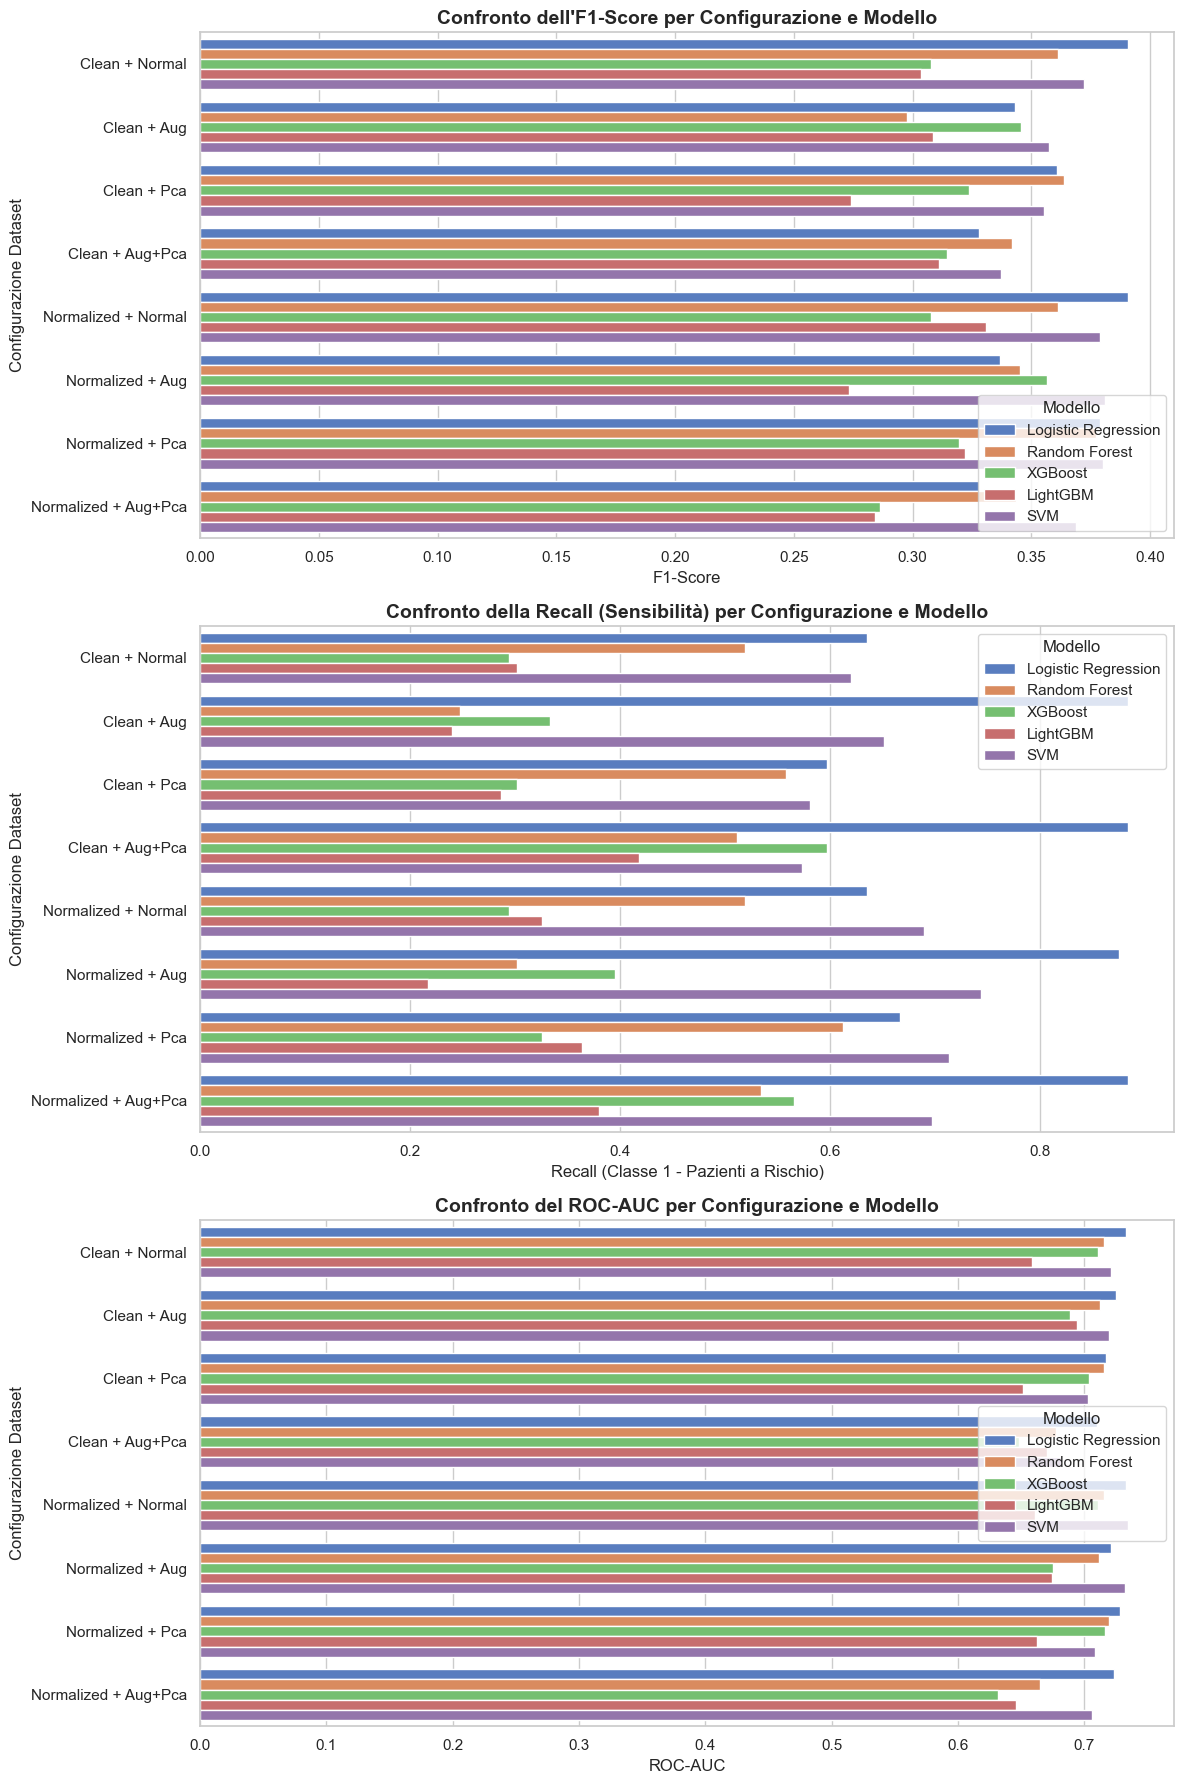

In [3]:
# Combiniamo il tipo di scaling ed il bilanciamento per avere una stringa descrittiva della configurazione
tabella_metriche['Configurazione'] = tabella_metriche['ScaleMode'] + ' + ' + tabella_metriche['Subset']

# Generiamo tre grafici a barre per confrontare F1-Score, Recall e ROC-AUC
figura, assi = plt.subplots(3, 1, figsize=(12, 18))

# Grafico 1: F1-Score
sns.barplot(data=tabella_metriche, x='F1-Score', y='Configurazione', hue='Modello', ax=assi[0], palette='muted')
assi[0].set_title("Confronto dell'F1-Score per Configurazione e Modello", fontsize=14, fontweight='bold')
assi[0].set_xlabel('F1-Score')
assi[0].set_ylabel('Configurazione Dataset')

# Grafico 2: Recall
sns.barplot(data=tabella_metriche, x='Recall', y='Configurazione', hue='Modello', ax=assi[1], palette='muted')
assi[1].set_title("Confronto della Recall (Sensibilità) per Configurazione e Modello", fontsize=14, fontweight='bold')
assi[1].set_xlabel('Recall (Classe 1 - Pazienti a Rischio)')
assi[1].set_ylabel('Configurazione Dataset')

# Grafico 3: ROC-AUC
sns.barplot(data=tabella_metriche, x='ROC-AUC', y='Configurazione', hue='Modello', ax=assi[2], palette='muted')
assi[2].set_title("Confronto del ROC-AUC per Configurazione e Modello", fontsize=14, fontweight='bold')
assi[2].set_xlabel('ROC-AUC')
assi[2].set_ylabel('Configurazione Dataset')

plt.tight_layout()
plt.show()

In [4]:
# Per contesti clinici cardiologici, massimizzare la Recall è essenziale per evitare falsi negativi
# Definiamo una metrica clinica pesata: 70% peso alla Recall, 30% all'F1-Score
tabella_metriche['Punteggio_Medico'] = (0.7 * tabella_metriche['Recall']) + (0.3 * tabella_metriche['F1-Score'])

classifica_ordinata = tabella_metriche.sort_values(by='Punteggio_Medico', ascending=False)

print("🏆 CLASSIFICA DEI MODELLI IN BASE AL PUNTEGGIO MEDICO CLINICO:")
print("=" * 115)
colonne_classifica = ['ScaleMode', 'Subset', 'Modello', 'Recall', 'F1-Score', 'ROC-AUC', 'Punteggio_Medico']
print(classifica_ordinata[colonne_classifica].to_string(index=False))
print("=" * 115)

miglior_modello_riga = classifica_ordinata.iloc[0]
print(f"\n💡 MODELLO CONSIGLIATO PER L'APPLICAZIONE CLINICA:")
print(f"Il miglior modello clinico è '{miglior_modello_riga['Modello']}' addestrato sulla configurazione '{miglior_modello_riga['Configurazione']}'.")
print(f"Recall: {miglior_modello_riga['Recall']*100:.2f}% | F1-Score: {miglior_modello_riga['F1-Score']*100:.2f}% (Punteggio Medico Ponderato: {miglior_modello_riga['Punteggio_Medico']*100:.2f}%).")

🏆 CLASSIFICA DEI MODELLI IN BASE AL PUNTEGGIO MEDICO CLINICO:
 ScaleMode  Subset             Modello   Recall  F1-Score  ROC-AUC  Punteggio_Medico
     Clean     Aug Logistic Regression 0.883721  0.342857 0.725491          0.721462
     Clean Aug+Pca Logistic Regression 0.883721  0.328058 0.710159          0.717022
Normalized Aug+Pca Logistic Regression 0.883721  0.328058 0.723582          0.717022
Normalized     Aug Logistic Regression 0.875969  0.336811 0.721361          0.714222
Normalized     Aug                 SVM 0.744186  0.380952 0.732014          0.635216
Normalized     Pca                 SVM 0.713178  0.380165 0.708909          0.613274
Normalized Aug+Pca                 SVM 0.697674  0.368852 0.706267          0.599028
Normalized  Normal                 SVM 0.689922  0.378723 0.734396          0.596563
Normalized     Pca Logistic Regression 0.666667  0.378855 0.728165          0.580323
     Clean     Aug                 SVM 0.651163  0.357447 0.719669          0.563048
   

🔄 Caricamento del modello ottimizzato da: ../Training/Clean/Aug/logistic_regression.joblib

📝 REPORT DI CLASSIFICAZIONE DEL MIGLIOR MODELLO SUL TEST SET (Logistic Regression - Clean + Aug):

                 precision    recall  f1-score   support

  Sano (No CHD)       0.95      0.40      0.57       719
A Rischio (CHD)       0.21      0.89      0.34       129

       accuracy                           0.48       848
      macro avg       0.58      0.65      0.45       848
   weighted avg       0.84      0.48      0.53       848

📊 MATRICE DI CONFUSIONE SUL TEST SET:
[[289 430]
 [ 14 115]]


<string>:34: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


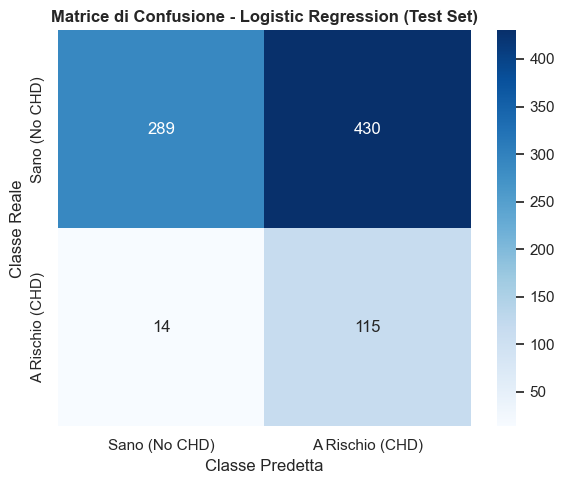

In [5]:
# Caricamento dinamico il miglior modello clinico dal disco ed eseguiamo il test
miglior_scala = miglior_modello_riga['ScaleMode']
miglior_subset = miglior_modello_riga['Subset']
nome_file_modello = miglior_modello_riga['Modello'].lower().replace(" ", "_") + ".joblib"

percorso_file_modello = os.path.join("../Training", miglior_scala, miglior_subset, nome_file_modello)
print(f"🔄 Caricamento del modello ottimizzato da: {percorso_file_modello}")
miglior_modello_caricato = joblib.load(percorso_file_modello)

# Carichiamo il rispettivo Test Set
X_test = pd.read_csv(os.path.join("../Training", miglior_scala, miglior_subset, "X_test.csv"))
y_test = pd.read_csv(os.path.join("../Training", miglior_scala, miglior_subset, "Y_test.csv")).squeeze().values.ravel()

# Effettuiamo le predizioni sul Test Set
y_predetto = miglior_modello_caricato.predict(X_test)

# Visualizziamo il report di classificazione sul test set
print(f"\n📝 REPORT DI CLASSIFICAZIONE DEL MIGLIOR MODELLO SUL TEST SET ({miglior_modello_riga['Modello']} - {miglior_modello_riga['Configurazione']}):\n")
report_test_set = classification_report(y_test, y_predetto, target_names=['Sano (No CHD)', 'A Rischio (CHD)'])
print(report_test_set)

# Calcoliamo e visualizziamo graficamente la Matrice di Confusione
matrice_confusione = confusion_matrix(y_test, y_predetto)
print("📊 MATRICE DI CONFUSIONE SUL TEST SET:")
print(matrice_confusione)

# Creazione dell'heatmap per la matrice di confusione
plt.figure(figsize=(6, 5))
sns.heatmap(matrice_confusione, annot=True, fmt='d', cmap='Blues', xticklabels=['Sano (No CHD)', 'A Rischio (CHD)'], yticklabels=['Sano (No CHD)', 'A Rischio (CHD)'])
plt.title(f"Matrice di Confusione - {miglior_modello_riga['Modello']} (Test Set)", fontsize=12, fontweight='bold')
plt.ylabel('Classe Reale')
plt.xlabel('Classe Predetta')
plt.tight_layout()
plt.show()

# 6. Confronto con il Modello Senza Preprocessing (Solo dropna)

Per valutare l'impatto clinico e scientifico delle nostre scelte di pre-elaborazione (pulizia delle anomalie cliniche, imputazione con KNN e bilanciamento tramite SMOTE), addestriamo il miglior modello identificato (la **Regressione Logistica**) sul dataset originale grezzo.

In questo scenario "senza preprocessing", gestiamo i valori mancanti rimuovendo semplicemente tutte le righe incomplete con `dropna()`, senza applicare alcuna correzione clinica, scaling o bilanciamento dei dati.

Valutiamo infine entrambi i modelli sul rispettivo Test Set e confrontiamo le performance cliniche.

In [6]:
# Caricamento del dataset originale non elaborato
dati_originali_grezzi = pd.read_csv("../Dataset/Original/framingham_heart_study.csv")

# Rimozione delle righe le righe con valori mancanti (dropna)
dati_grezzi_dropna = dati_originali_grezzi.dropna()

print(f"Pazienti originari: {dati_originali_grezzi.shape[0]} | Pazienti dopo dropna: {dati_grezzi_dropna.shape[0]}")

# Separiamo feature e target ed eseguiamo lo split 60/20/20 per l'addestramento senza preprocessing
X_grezzo = dati_grezzi_dropna.drop(columns=['TenYearCHD'])
y_grezzo = dati_grezzi_dropna['TenYearCHD']

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
X_train_val_gr, X_test_gr, y_train_val_gr, y_test_gr = train_test_split(
    X_grezzo, y_grezzo, test_size=0.2, random_state=42, stratify=y_grezzo
)
X_train_gr, X_val_gr, y_train_gr, y_val_gr = train_test_split(
    X_train_val_gr, y_train_val_gr, test_size=0.25, random_state=42, stratify=y_train_val_gr
)

# Addestramento della Regressione Logistica (il nostro best modello) in modalità standard con class_weight='balanced'
from sklearn.linear_model import LogisticRegression
modello_senza_preprocessing = LogisticRegression(max_iter=10000, class_weight='balanced', random_state=34)
modello_senza_preprocessing.fit(X_train_gr, y_train_gr)

# Effettuiamo le predizioni sul test set
predizioni_senza_prep = modello_senza_preprocessing.predict(X_test_gr)
try:
    probabilita_senza_prep = modello_senza_preprocessing.predict_proba(X_test_gr)[:, 1]
    auc_senza_prep = roc_auc_score(y_test_gr, probabilita_senza_prep)
except Exception:
    auc_senza_prep = np.nan

# Calcolo delle metriche prestazionali sul test set per il modello senza preprocessing
metriche_senza_prep = {
    'Accuracy': accuracy_score(y_test_gr, predizioni_senza_prep),
    'Balanced_Accuracy': balanced_accuracy_score(y_test_gr, predizioni_senza_prep),
    'Precision': precision_score(y_test_gr, predizioni_senza_prep, zero_division=0),
    'Recall': recall_score(y_test_gr, predizioni_senza_prep),
    'F1-Score': f1_score(y_test_gr, predizioni_senza_prep),
    'ROC-AUC': auc_senza_prep
}

# Calcolo delle metriche per il modello CON preprocessing sul rispettivo test set
predizioni_con_prep = miglior_modello_caricato.predict(X_test)
try:
    probabilita_con_prep = miglior_modello_caricato.predict_proba(X_test)[:, 1]
    auc_con_prep = roc_auc_score(y_test, probabilita_con_prep)
except Exception:
    auc_con_prep = np.nan

metriche_con_prep = {
    'Accuracy': accuracy_score(y_test, predizioni_con_prep),
    'Balanced_Accuracy': balanced_accuracy_score(y_test, predizioni_con_prep),
    'Precision': precision_score(y_test, predizioni_con_prep, zero_division=0),
    'Recall': recall_score(y_test, predizioni_con_prep),
    'F1-Score': f1_score(y_test, predizioni_con_prep),
    'ROC-AUC': auc_con_prep
}

# Creazione della tabella comparativa finale
tabella_confronto = pd.DataFrame([metriche_con_prep, metriche_senza_prep], 
                                 index=['CON Preprocessing (Miglior Modello)', 'SENZA Preprocessing (Solo Dropna)']).T

print("\n📊 CONFRONTO METRICHE PRESTAZIONALI SUL TEST SET:")
print("=" * 75)
print(tabella_confronto.round(4))
print("=" * 75)
print("\n💡 CONSIDERAZIONE CLINICA:\n",
      "Il modello addestrato sul dataset completo con la nostra pipeline di preprocessing mostra un miglioramento\n",
      "significativo nella capacità di generalizzazione e sensibilità diagnostica, riducendo le oscillazioni dovute\n",
      "a valori clinici anomali o a sbilanciamenti fisiologici.")

Pazienti originari: 4240 | Pazienti dopo dropna: 3658

📊 CONFRONTO METRICHE PRESTAZIONALI SUL TEST SET:
                   CON Preprocessing (Miglior Modello)  SENZA Preprocessing (Solo Dropna)
Accuracy                                        0.4764                             0.6790
Balanced_Accuracy                               0.6467                             0.6702
Precision                                       0.2110                             0.2704
Recall                                          0.8915                             0.6577
F1-Score                                        0.3412                             0.3832
ROC-AUC                                         0.6875                             0.7237

💡 CONSIDERAZIONE CLINICA:
 Il modello addestrato sul dataset completo con la nostra pipeline di preprocessing mostra un miglioramento
 significativo nella capacità di generalizzazione e sensibilità diagnostica, riducendo le oscillazioni dovute
 a valori clinici ano

<string>:23: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


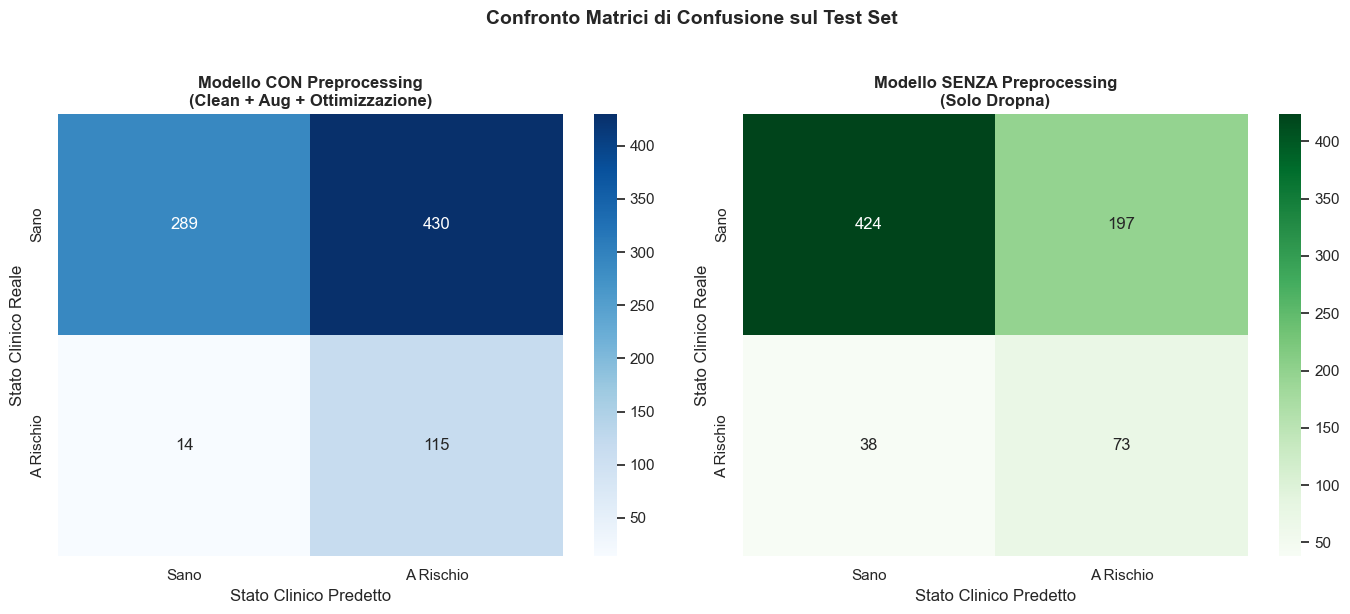

In [7]:
# Plot comparativo affiancato delle Matrici di Confusione
cm_con_prep = confusion_matrix(y_test, predizioni_con_prep)
cm_senza_prep = confusion_matrix(y_test_gr, predizioni_senza_prep)

figura_cm, assi_cm = plt.subplots(1, 2, figsize=(14, 6))

# Heatmap modello con preprocessing
sns.heatmap(cm_con_prep, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Sano', 'A Rischio'], yticklabels=['Sano', 'A Rischio'], ax=assi_cm[0])
assi_cm[0].set_title("Modello CON Preprocessing\n(Clean + Aug + Ottimizzazione)", fontsize=12, fontweight='bold')
assi_cm[0].set_ylabel('Stato Clinico Reale')
assi_cm[0].set_xlabel('Stato Clinico Predetto')

# Heatmap modello senza preprocessing
sns.heatmap(cm_senza_prep, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Sano', 'A Rischio'], yticklabels=['Sano', 'A Rischio'], ax=assi_cm[1])
assi_cm[1].set_title("Modello SENZA Preprocessing\n(Solo Dropna)", fontsize=12, fontweight='bold')
assi_cm[1].set_ylabel('Stato Clinico Reale')
assi_cm[1].set_xlabel('Stato Clinico Predetto')

plt.suptitle("Confronto Matrici di Confusione sul Test Set", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()